In [125]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import  StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import LeaveOneOutEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [126]:
df = pd.read_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\fs\feature_selected_properties.csv")
df

,total_area_sqft,property_type,sector,plot_area_missing,bathrooms,society,area_per_bedroom,servant_room,bedrooms,furnishing_type,balcony,facing,luxury_category,age_possession,pooja_room,price_in_cr
0,1800.0,Independent House,sector 84,1,4,SS Linden Floors,450.000000,0,4,Unfurnished,2,north-east,Luxury,New Property,0,2.76
1,2700.0,Independent Builder Floor,sector 26,1,3,"Block E DLF City Phase 1, Gurgaon",900.000000,0,3,Unfurnished,2,not available,Budget,New Property,0,4.25
2,4000.0,Independent Builder Floor,sector 43,1,4,"Sushant Lok Phase 1, Gurgaon",1000.000000,1,4,Furnished,2,east,Budget,Relatively New,1,5.25
3,4500.0,Independent House,sector 109,0,5,International City by SOBHA Phase 2,1125.000000,1,4,Unfurnished,3+,west,Budget,Relatively New,0,9.00
4,2002.0,Flat,sector 106,1,3,godrej meridien,667.333333,1,3,Unfurnished,3,east,Budget,New Property,0,3.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,2250.0,Independent House,sector 33,0,4,Central Park Flower Valley Fleur Villas,562.500000,1,4,Semi-Furnished,3+,north-west,Luxury,Relatively New,1,7.15
5527,1656.0,Independent Builder Floor,sector 76,1,2,Whiteland Blissville,552.000000,0,3,Unfurnished,2,north-east,Luxury,New Property,0,2.15
5528,1024.0,Independent Builder Floor,sector 33,1,2,Signature Global Park,512.000000,0,2,Unfurnished,3,north-east,Luxury,New Property,0,0.95
5529,2650.0,Independent Builder Floor,sector 57,1,4,Huda Flats,662.500000,1,4,Semi-Furnished,2,east,Luxury,New Property,1,3.50


In [127]:
X = df.drop(columns= ['price_in_cr'])
y = df['price_in_cr']

y_log = np.log1p(y)

In [128]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['total_area_sqft', 'plot_area_missing', 'bathrooms', 'area_per_bedroom', 'servant_room', 'bedrooms', 'pooja_room']
Categorical columns: ['property_type', 'sector', 'society', 'furnishing_type', 'balcony', 'facing', 'luxury_category', 'age_possession']


In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [130]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ), cat_cols)
    ]
)

In [131]:
linear_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

In [132]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    linear_pipeline,
    X,
    y_log,
    cv=kfold,
    scoring="r2"
)

print("CV Mean:", scores.mean())
print("CV Std:", scores.std())

CV Mean: 0.8820247522714395
CV Std: 0.015402121441797293


In [133]:
linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [134]:
y_pred_log = linear_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [135]:

print("Test R2:", r2_score(y_true, y_pred))
print("Test MAPE:", mean_absolute_percentage_error(y_true, y_pred)*100)

Test R2: 0.7951277371646533
Test MAPE: 21.007835357737697


In [136]:
ridge_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=0.0001))
])

ridge_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [137]:
preprocessor = ridge_pipeline.named_steps["preprocessor"]
model = ridge_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

feature_names


array(['num__total_area_sqft', 'num__plot_area_missing', 'num__bathrooms',
       'num__area_per_bedroom', 'num__servant_room', 'num__bedrooms',
       'num__pooja_room', 'cat__property_type_Independent Builder Floor',
       'cat__property_type_Independent House', 'cat__sector_farukhnagar',
       'cat__sector_gwal pahari', 'cat__sector_sector 1',
       'cat__sector_sector 10', 'cat__sector_sector 101',
       'cat__sector_sector 102', 'cat__sector_sector 103',
       'cat__sector_sector 104', 'cat__sector_sector 105',
       'cat__sector_sector 106', 'cat__sector_sector 107',
       'cat__sector_sector 108', 'cat__sector_sector 109',
       'cat__sector_sector 11', 'cat__sector_sector 110',
       'cat__sector_sector 111', 'cat__sector_sector 112',
       'cat__sector_sector 113', 'cat__sector_sector 12',
       'cat__sector_sector 13', 'cat__sector_sector 14',
       'cat__sector_sector 15', 'cat__sector_sector 17',
       'cat__sector_sector 2', 'cat__sector_sector 21',
       'ca

In [151]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_
}).sort_values("coef", ascending=False)

coef_df

,feature,coef
232,"cat__society_Civil Lines, Gurgaon",1.061622
739,cat__society_dlf the crest,0.945856
373,cat__society_Lotus Floors,0.944550
737,cat__society_dlf the aralias,0.941541
272,cat__society_DLF The Crest,0.854349
...,...,...
936,cat__society_trimurti villas bhiwadi,-1.185099
320,"cat__society_Green Heritage Villas, Jhajjar",-1.221281
375,cat__society_Luxurious Villa dlf Phase-1,-1.249889
621,cat__society_Ultra Luxurious villa,-1.346248


In [139]:
coef_df.to_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\notebooks\insight_module\insight_coefficients.csv", index=False)


#### Get Transformed DataFrame

In [153]:
X_transformed = preprocessor.transform(X)

transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

transformed_df

,num__total_area_sqft,num__plot_area_missing,num__bathrooms,num__area_per_bedroom,num__servant_room,num__bedrooms,num__pooja_room,cat__property_type_Independent Builder Floor,cat__property_type_Independent House,cat__sector_farukhnagar,...,cat__facing_south,cat__facing_south-east,cat__facing_south-west,cat__facing_west,cat__luxury_category_Luxury,cat__luxury_category_Semi-Luxury,cat__age_possession_New Property,cat__age_possession_Old Property,cat__age_possession_Relatively New,cat__age_possession_Under Construction
0,-0.513990,0.650358,0.039957,-0.869204,-1.116614,0.174452,-0.766772,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.151626,0.650358,-0.543441,0.822223,-1.116614,-0.461800,-0.766772,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.113071,0.650358,0.039957,1.198096,0.895565,0.174452,1.304168,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.482857,-1.537615,0.623355,1.667937,0.895565,0.174452,-0.766772,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.364596,0.650358,-0.543441,-0.052307,0.895565,-0.461800,-0.766772,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,-0.181182,-1.537615,0.039957,-0.446347,0.895565,0.174452,1.304168,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5527,-0.620489,0.650358,-1.126840,-0.485814,-1.116614,-0.461800,-0.766772,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5528,-1.087899,0.650358,-1.126840,-0.636163,-1.116614,-1.098052,-0.766772,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5529,0.114647,0.650358,0.039957,-0.070474,0.895565,0.174452,1.304168,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [141]:
transformed_df.to_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\notebooks\insight_module\X_transformed_df.csv", index=False)


In [148]:
COEFS = dict(zip(coef_df["feature"], coef_df["coef"]))
COEFS

{'cat__society_Civil Lines, Gurgaon': 1.0616219745282718,
 'cat__society_dlf the crest': 0.9458561718741664,
 'cat__society_Lotus Floors': 0.9445501074834134,
 'cat__society_dlf the aralias': 0.941540824023182,
 'cat__society_DLF The Crest': 0.8543490275953237,
 'cat__society_Emaar The Palm Springs': 0.8421489756958009,
 'cat__sector_sector 28': 0.8240839258810204,
 'cat__sector_sector 25': 0.7832413287410608,
 'cat__sector_sector 26': 0.7516581600510263,
 'cat__society_Unitech Vista Villas': 0.7375231378445903,
 'cat__society_Sector 15, Gurgaon': 0.7368177129109593,
 'cat__society_Sector 11, Gurgaon': 0.7071790713884522,
 'cat__society_dlf the belaire': 0.6837987128526658,
 'cat__society_Golf Course Ext Road, Gurgaon': 0.6633553344474359,
 'cat__society_Part 3 Sector 5, Gurgaon': 0.6528625501909845,
 'cat__society_executive villas lane': 0.6412643359871054,
 'cat__society_Om Nagar, Gurgaon': 0.6371058484585981,
 'cat__society_central park resorts': 0.6312288800430542,
 'cat__society_t

In [149]:
COEFS['cat__society_Civil Lines, Gurgaon']

1.0616219745282718

In [154]:
COEFS['num__total_area_sqft']

0.22794855070477452

In [155]:
scaler = linear_pipeline.named_steps["preprocessor"].named_transformers_["num"]

area_std = scaler.scale_[num_cols.index("total_area_sqft")]

In [157]:
scaled_delta = 100 / area_std

log_price_change = COEFS["num__total_area_sqft"] * scaled_delta
log_price_change

0.016858461099198845

## Insight Module

If feature X changes by Δ, how does price change?

1. Fitted Regression Model :

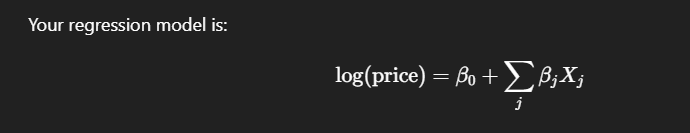

This means:

The log of price is a linear function of the features.

2️. What does this equation mean in plain algebra?

The equation is saying:

log(price) = some number

To get price, we must undo the log.

The inverse of log(·) is exp(·).

So apply exponentiation on both sides.

3. Undo the Log :

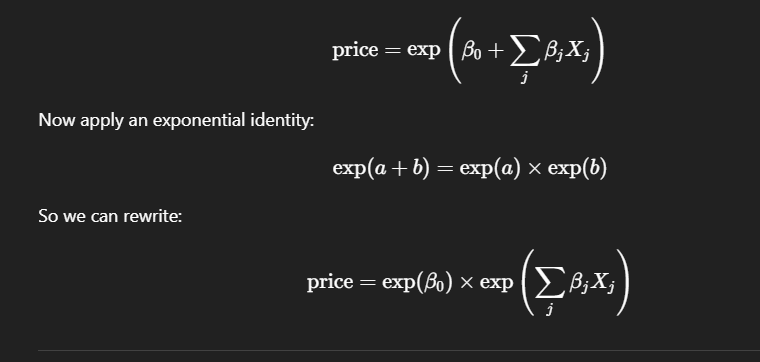

4. Define the Base Price :

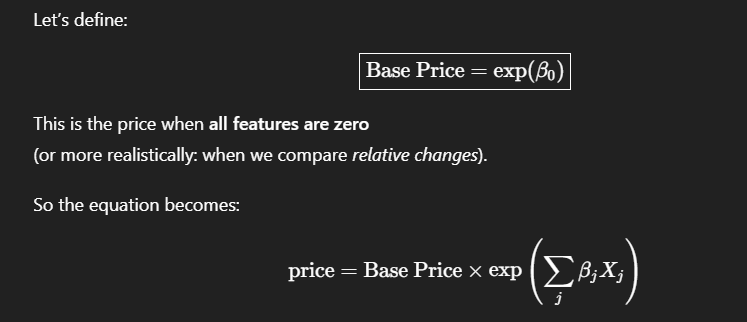

5. Introduce Change Δ :

In the Insight Module, we are not asking:

“What is the absolute price?”

We are asking:

“What happens to price when features change?”

So consider:

1. A baseline property

2. A new property where some features changed

6. Price For Two Scanario :

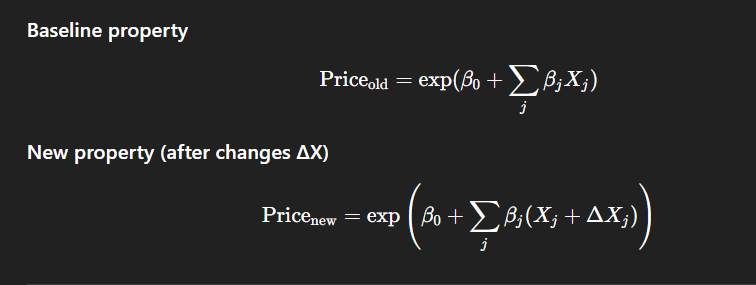

7. Expand the New Price :

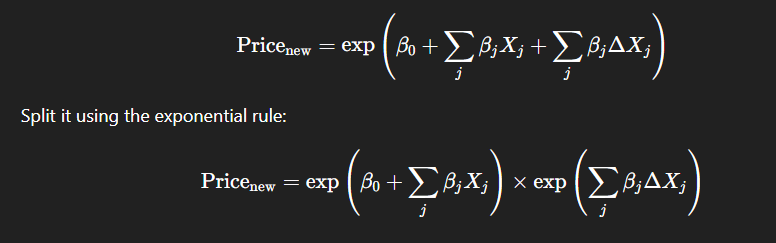

8. Substitute the Old Price :

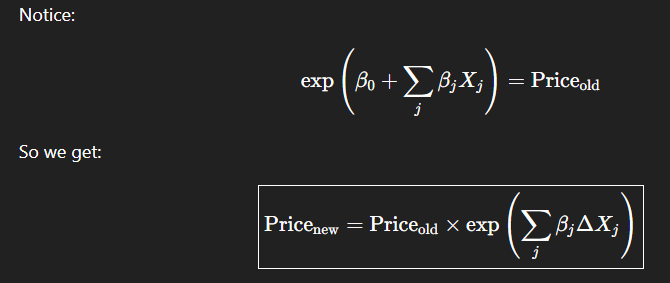

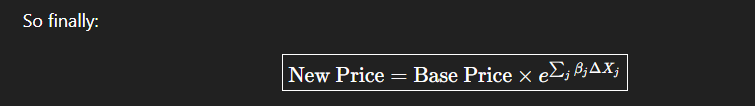

Example :

β_area = 0.000164

For every extra 1 sqft, the log of price increases by 0.000164.

ΔArea = 100 sqft

So the total effect on log(price) is:

∑𝛽𝑗Δ𝑋𝑗 = 0.0164

Adding 100 sqft causes a 1.64% increase in log-price units.

This is NOT yet a 1.64% price increase but it’s a change in log(price).

Model predicts log(price), but real prices are in rupees. so We need to remove the log so we are taking exponent

New Price = Base Price × 𝑒^0.0164

New Price = Base Price x 1.0165

A log-price increase of 0.0164 corresponds to a 1.65% multiplicative increase in price.

Base Price :

1. 3 Cr

New Price = 3.0495

Absolute increase:

3.0495 − 3.0000 = 0.0495 Cr = ₹ 4.95 𝐿

Adding 100 sqft increases property price by ~1.65%.
For a ₹3 Cr home, that translates to about ₹5 lakh.

2. 5 Cr

Step 1: Apply multiplier

New Price = 5 × 1.0165 = 5.0825 Cr

Step 2: Absolute change

5.0825 − 5.0000 = 0.0825 Cr = ₹8.25L

Interpretation

For a ₹5 Cr property, adding 100 sqft increases the price by ~₹8.25 lakh (1.65%).

3. Very High-End Property (₹10 Cr)

Step 1: Apply multiplier

New Price = 10 × 1.0165 = 10.165 Cr

Step 2: Absolute change

10.165 − 10.000 = 0.165 Cr = ₹16.5L

Interpretation

For a ₹10 Cr property, adding 100 sqft increases the price by ~₹16.5 lakh (1.65%).

Conclusion : The model estimates that every additional 100 sqft increases property value by approximately 1.65%, regardless of the base price. As a result, higher-priced properties experience larger absolute price gains in rupee terms, while the proportional impact remains consistent across price segments.

Suppose:

Old price = O

New price = N

Then by definition:

Absolute price change =  N − O

Percentage price change

Percentage Change = ( N - O ) / O * 100
	​
Instead of writing the new price directly, we often write:


N = O × M

Where M is the price multiplier and O is the Old Price

Examples:

If price increases by 5% → 𝑀 = 1.05
If price decreases by 10% → M = 0.90
If no change → M = 1.00

Substitute multiplier into absolute change

Recall:

Absolute Change = N - O

Substitute 

N = O × M:


Absolute Change = (O × M )− O

Factor out O

Absolute Change = O × (M − 1)

So, abs_change = BASE_PRICE * (price_multiplier - 1)

Start again from definition:

Percentage Change = ( N - O ) / O * 100

Substitute 

N = O × M:

Percentage Change = ( O X M - O ) / O * 100

Factor out O

Percentage Change =  (M−1) × 100

So, pct_change = (price_multiplier - 1) * 100


Once you know the multiplier M:

Percentage change = (M − 1) × 100

Absolute change = Base Price × (M − 1)

### Bedrooms

In [54]:
df["bedrooms"].value_counts().sort_index()


bedrooms
1       22
2      605
3     2248
4     1694
5      406
6      210
7       56
8       50
9       69
10      26
11       5
12      17
13       2
14       1
15       3
16       7
17       2
18       1
19       1
20       2
24       1
Name: count, dtype: int64

Bedroom impact reflects the average incremental value of an additional bedroom, primarily learned from 2–4 BHK properties where market activity is highest. Estimates for extreme bedroom changes are extrapolations.

### Utility Features : Servent Room and Store Room

Among utility features, servant rooms command a higher premium than store rooms.
Both features add value, but servant rooms typically command a higher premium because they reflect a lifestyle upgrade rather than just storage.”

### Sector

How expensive is this location, relative to an average Gurgaon location, after adjusting for everything else? So sector insight is comparative, not incremental.

We trained the model using mean / leave-one-out encoding for sector.

That means:

each sector is represented by a single numeric value

that value already captures:

micro-location quality

reputation

buyer willingness to pay

So the correct question is:

If a property belongs to this sector, how much higher/lower is its price relative to the average sector?

Why mean / LOO encoding is the right choice here

Mean / LOO encoding does something very powerful:

It converts:

categorical location → continuous “location quality score”

So the model learns:

“Higher score ⇒ higher willingness to pay”

That gives you:

smooth ordering of sectors

stable coefficients

meaningful % interpretation

That’s why your current sector insight feels clean and believable.

### Sector A vs Sector B Comparison

Step 1: What LOO / Mean Encoding actually does 

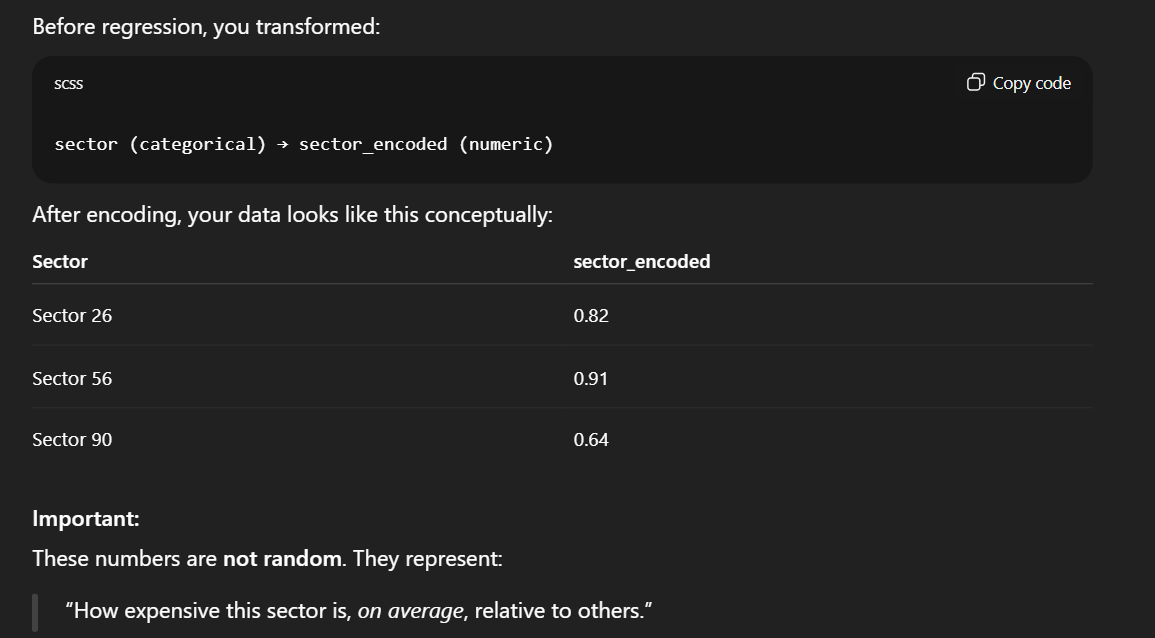
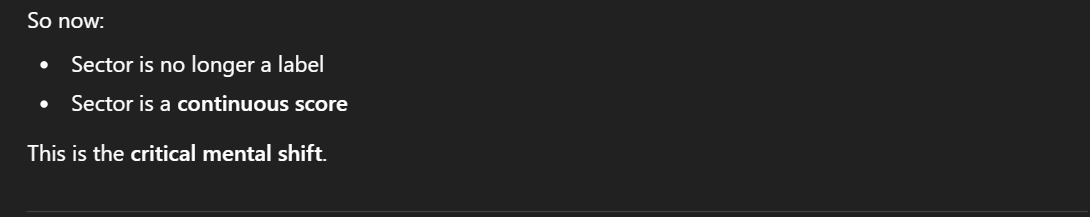

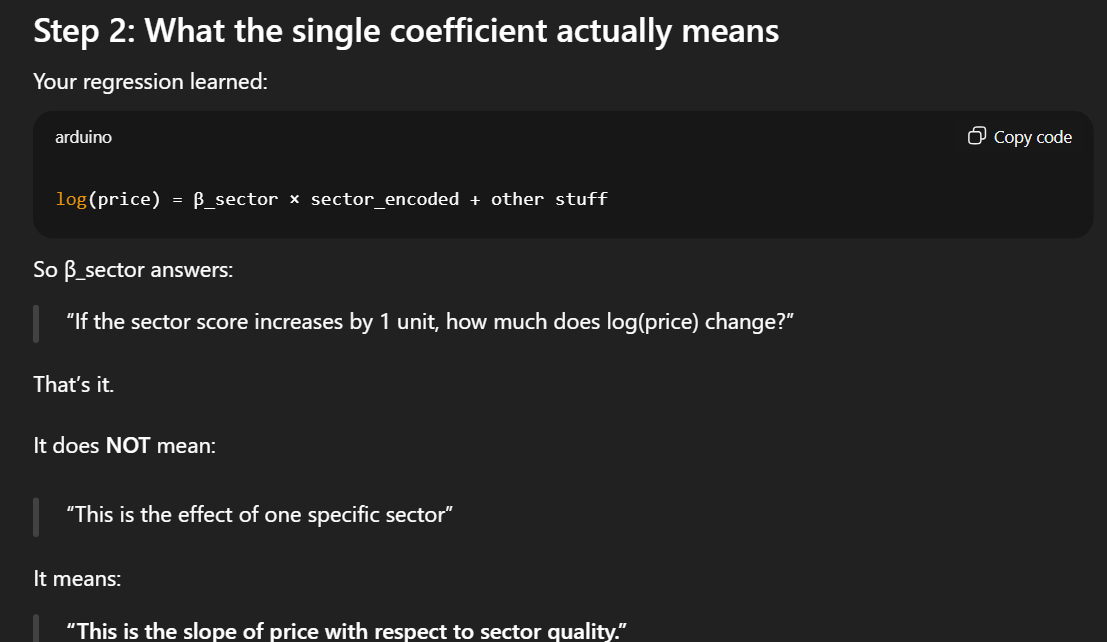

Mean encoding turns “sector” into a numeric location-quality score, and the single coefficient tells you how price changes as that score improves.

### Facing

In [55]:
df['facing'].value_counts()

facing
east             1530
north-east       1388
north             845
west              429
not available     420
north-west        296
south-east        201
south             186
south-west        133
Name: count, dtype: int64